In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.partial_sc import partial_sc


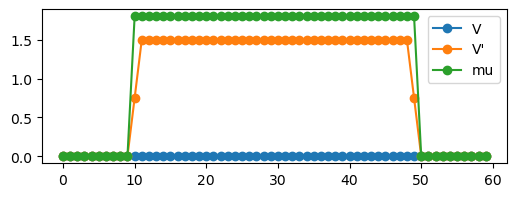

In [2]:
widthD = 10
widthF = 1
widthP = 40

X, Y = widthD+widthP+widthD, 200
lattice = Lattice(X, Y)

t = 1
T = 0.001

muD = 0.0 * t
muP = 1.8 * t
muF = 1.4 * t
muN = 1.2 * t
mu = np.zeros(lattice.X)
mu[:widthD] = muD
mu[widthD:widthD + widthP] = muP
mu[widthD + widthP:widthD + widthP + widthD] = muD

h0 = 0.9 * t
h = np.zeros_like(mu)


U0 = 0.0 * t
U = U0 * np.ones(lattice.X)
U[widthD:] = 0
U[widthD-1] = U0/2

V0 = 0 * t
V = V0 * np.ones(lattice.X)
V[widthD:-widthD] = 0
V[widthD-1] = V0/2
V[-widthD] = V0/2


V_prime0 = 1.5 * t
V_prime = V_prime0 * np.ones(lattice.X)
V_prime[:widthD] = 0
V_prime[widthD+widthP:] = 0
V_prime[widthD] = V_prime0/2
V_prime[widthD+widthP-1] = V_prime0/2

# bulk p-wave F=0.018
plt.figure(figsize=(6,2))
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, '-o', label='mu')
# plt.plot(h, '-o', label='hz')
plt.legend()
# plt.xlim(85,100)
# plt.xlim(0,15)


In [3]:
from scripts.utils import is_hermitian

H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
                # F_init=[0.23, 0.23, -0.23, -0.23],
                Fuu_init=[0.01, -0.01, 0.01j, -0.01j],
                Fdd_init=[-0.01, 0.01, 0.01j, -0.01j],
                hx=h)

print(is_hermitian(H.build_H_k(np.pi/4)))
print(is_hermitian(H.build_H_k0()))
print(is_hermitian(H.build_H_kindep()))

True
True
True


In [4]:
# F, Fuu, Fdd = H.get_correlations()

# x = np.arange(0, widthD + widthF + widthP+ widthF + widthD)

# fig, axs = plt.subplots(1, 1, figsize=(8, 6))
# axs.set_title(f"V/t = 5, V'/t= 1.5, T/t={T}, hx/t={h0}")

# axs.axvline(widthD, color='black', linestyle='--')
# axs.axvline(widthD-1, color='black', linestyle='--')
# axs.axvline(widthD + widthF + widthP, color='black', linestyle='--')
# axs.axvline(widthD + widthF + widthP+1, color='black', linestyle='--')

# # axs.plot(x, np.real(H.F0), label="onsite")
# # axs.plot(x, np.real(F.dwave), label="F.dwave")
# # axs.plot(x, np.real(F.swave), label="F.swave")

# axs.plot(x, np.real(F.px), label="ud:p_x-wave")
# axs.plot(x, np.imag(F.py), "--", label="ud:p_y-wave")

# # axs.plot(x, np.real(Fuu.px-Fdd.px)/2, label="uu:p_x-wave")
# # axs.plot(x, np.imag(Fuu.py+Fdd.py)/2, "--", label="uu:p_y-wave")
# axs.set_xlabel("x", fontsize=15)

# axs.legend()
# plt.show()

In [5]:
from scripts.self_consistency import bdg_sc

fixed_sites = (V_prime == 0)
fixed_syms = ["F_xplus", "F_xmin", "F_yplus", "F_ymin"]
partial_sc(H, temperature=T,
           fixed_sites=fixed_sites,
           fixed_syms=fixed_syms,
           atol=1e-4, rtol=1e-2, maxiter=500, 
           verbose=True)
# bdg_sc(H, temperature=T,
#            atol=1e-3, rtol=1e-1, maxiter=500, 
#            verbose=True)
F, Fuu, Fdd = H.get_correlations()

F0:
Absolute error: 4.539984540845612e-16
Relative error: 0.00045399845408456124
Average old: 0j
Average: (-3.12187951538358e-17+0j)
F_xplus:
Absolute error: 4.601127770460368e-17
Relative error: 4.601127770460368e-05
Average old: 0j
Average: (4.677555476221565e-19+0j)
F_xmin:
Absolute error: 7.112321614087746e-17
Relative error: 7.112321614087746e-05
Average old: 0j
Average: (5.695674706871975e-18+0j)
F_yplus:
Absolute error: 4.091508043852136e-17
Relative error: 4.091508043852136e-05
Average old: 0j
Average: (-8.495559080669532e-19-1.7634088012691755e-20j)
F_ymin:
Absolute error: 4.091508043852136e-17
Relative error: 4.091508043852136e-05
Average old: 0j
Average: (-8.495559080669532e-19+1.7634088012691755e-20j)
Fuu_xplus:
Absolute error: 0.014662716676399606
Relative error: 4589459770.7534895
Average old: (0.006779661016949152+0j)
Average: (0.005876519828539798+0j)
Fuu_xmin:
Absolute error: 0.014666399406850683
Relative error: 4592867652.717292
Average old: (-0.006779661016949152+0j)

1.2675097603713298e-12


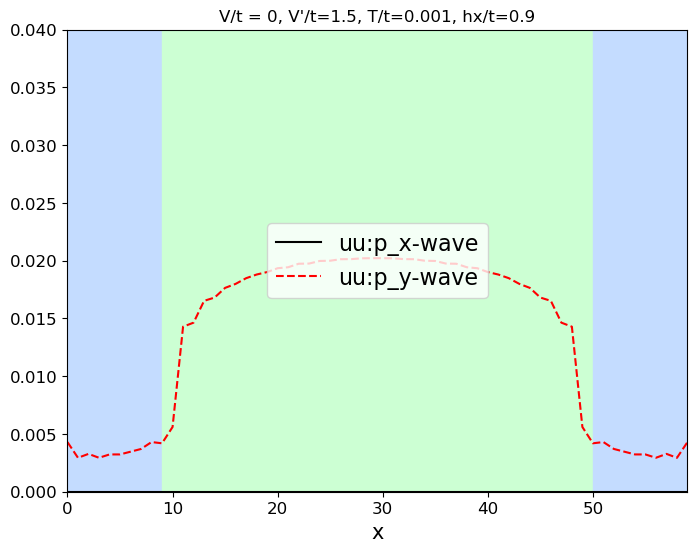

In [6]:
x = np.arange(0, widthD + widthP + widthD)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"V/t = {V0}, V'/t={V_prime0}, T/t={T}, hx/t={h0}")

axs.axvspan(0, widthD, color='#C4DCFF')

axs.axvspan(widthD-1, widthD + widthP, color='#CCFFD3')
axs.axvspan(widthD + widthP,  widthD + widthP + widthD, color='#C4DCFF')

# axs.plot(x, np.real(H.F0), label="onsite")
# axs.plot(x, np.real(F.dwave), label="F.dwave")
# axs.plot(x, np.real(F.swave), label="F.swave")

# axs.plot(x, np.real(F.px), label="ud:p_x-wave")
# axs.plot(x, np.imag(F.py), "--", label="ud:p_y-wave")

axs.plot(x, np.real(Fuu.px-Fdd.px)/2, label="uu:p_x-wave", color='black')
axs.plot(x, np.imag(Fuu.py+Fdd.py)/2, "--", label="uu:p_y-wave", color='red')
axs.set_xlabel("x", fontsize=15)

# axs.set_yticks([0.0, 0.01, 0.02, 0.03, 0.04])

axs.tick_params(axis='both', labelsize=12)

axs.set_ylim(0.0, 0.04)
axs.set_xlim(0.0, 59)


axs.legend(fontsize=16, loc='center')
print(np.real(Fuu.px-Fdd.px)[30]/2)

# plt.savefig("../figures/DFPFD.svg", bbox_inches='tight')
plt.show()

In [8]:
print(H.free)

-24419.101534355435
